# Topic A — Analysis Notebook
Load experiment results, generate plots, extract key findings.

In [71]:
# Cell 1: Load all results
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

os.makedirs('plots_a', exist_ok=True)

results = {}
for f in sorted(glob.glob('results_a/*.json')):
    name = Path(f).stem
    with open(f) as fh:
        results[name] = json.load(fh)

def ci_95(vals):
    vals = np.array(vals)
    if len(vals) < 2: return 0.0
    return 1.96 * np.std(vals) / np.sqrt(len(vals))

def get_acc(name, key='student_g'):
    if name not in results: return [], 0, 0
    vals = np.array(results[name]['accuracies'][key]) * 100
    return vals, vals.mean(), ci_95(vals)

print(f'Loaded {len(results)} experiment results:')
for name in results:
    print(f'  {name}')

Loaded 46 experiment results:
  active_noise_entropy
  active_noise_var
  baseline
  bigv_4096
  bigv_4096_subset512
  clip_01
  clip_05
  clip_10
  curriculum_blocked
  curriculum_interleaved
  distill_ep_1
  distill_ep_10
  distill_ep_2
  distill_ep_20
  distill_ep_5
  distill_ep_50
  freeze_aux
  freeze_aux_unfreeze_ep3
  loss_fwd_kl_T05
  loss_fwd_kl_T2
  loss_js
  loss_rev_kl
  lr_0.0001
  lr_0.0003
  lr_0.001
  lr_0.003
  lr_0.01
  maximize_v1
  maximize_v2
  maximize_v3
  noise_gaussian
  noise_mnist
  noise_structured
  noise_uniform
  noise_zeros
  pretrain_contrastive
  pretrain_masked_recon
  pretrain_sup_lora16
  pretrain_sup_lora4
  pretrain_supervised
  teacher_ep_1
  teacher_ep_10
  teacher_ep_20
  teacher_ep_3
  teacher_ep_5
  weight_tracking


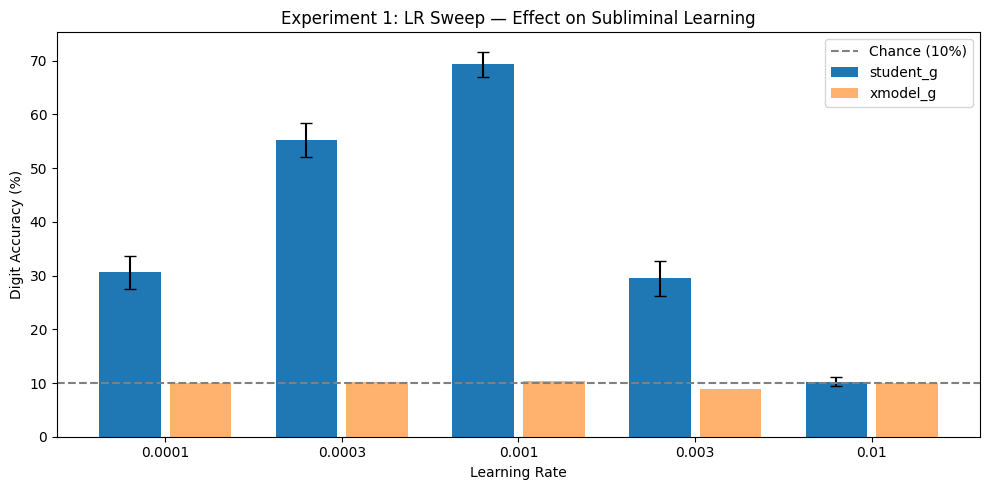

Optimal LR: 0.001 → student_g 69.3% ± 2.4%


In [72]:
# Cell 2: LR Sweep
lr_names = sorted([k for k in results if k.startswith('lr_')],
                   key=lambda x: float(x.split('_')[1]))
if lr_names:
    fig, ax = plt.subplots(figsize=(10, 5))
    lrs = [r.split('_')[1] for r in lr_names]
    sg_means = [get_acc(n, 'student_g')[1] for n in lr_names]
    sg_cis   = [get_acc(n, 'student_g')[2] for n in lr_names]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in lr_names]
    ref_means = [get_acc(n, 'reference')[1] for n in lr_names]
    x = np.arange(len(lr_names))
    ax.bar(x - 0.2, sg_means, 0.35, yerr=sg_cis, label='student_g', capsize=4)
    ax.bar(x + 0.2, xg_means, 0.35, label='xmodel_g', alpha=0.6)
    ax.axhline(y=10, color='gray', ls='--', label='Chance (10%)')
    ax.set_xticks(x); ax.set_xticklabels(lrs)
    ax.set_xlabel('Learning Rate'); ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Experiment 1: LR Sweep — Effect on Subliminal Learning')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/lr_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    best_idx = np.argmax(sg_means)
    print(f'Optimal LR: {lrs[best_idx]} → student_g {sg_means[best_idx]:.1f}% ± {sg_cis[best_idx]:.1f}%')
else:
    print('No LR sweep results found.')

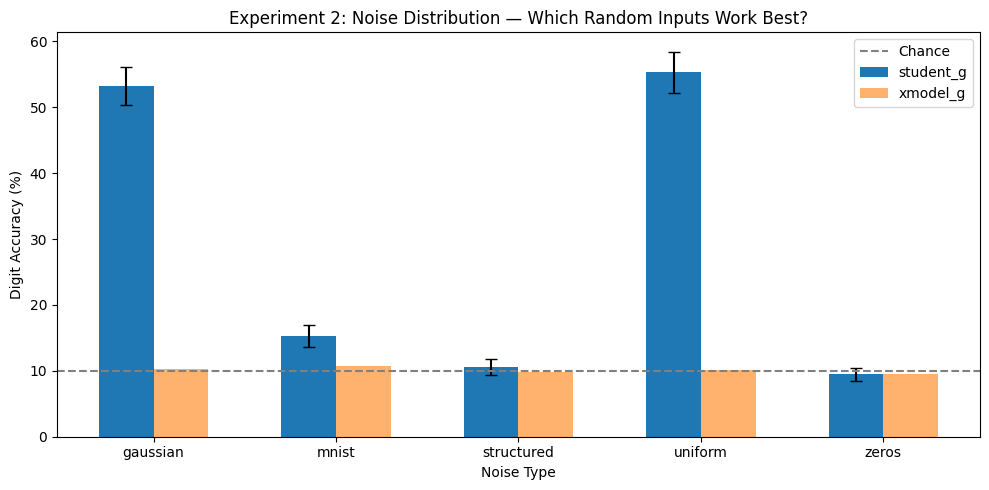

Noise ranking: uniform(55.3%) > gaussian(53.2%) > mnist(15.3%) > structured(10.6%) > zeros(9.5%)


In [73]:
# Cell 3: Noise Distribution
noise_names = sorted([k for k in results if k.startswith('noise_')])
if noise_names:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [n.replace('noise_', '') for n in noise_names]
    sg_means = [get_acc(n, 'student_g')[1] for n in noise_names]
    sg_cis = [get_acc(n, 'student_g')[2] for n in noise_names]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in noise_names]
    x = np.arange(len(noise_names))
    ax.bar(x - 0.15, sg_means, 0.3, yerr=sg_cis, label='student_g', capsize=4)
    ax.bar(x + 0.15, xg_means, 0.3, label='xmodel_g', alpha=0.6)
    ax.axhline(y=10, color='gray', ls='--', label='Chance')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel('Noise Type'); ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Experiment 2: Noise Distribution — Which Random Inputs Work Best?')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/noise_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    ranked = sorted(zip(labels, sg_means), key=lambda x: x[1], reverse=True)
    print(f'Noise ranking: {" > ".join([f"{n}({m:.1f}%)" for n,m in ranked])}')
else:
    print('No noise distribution results found.')

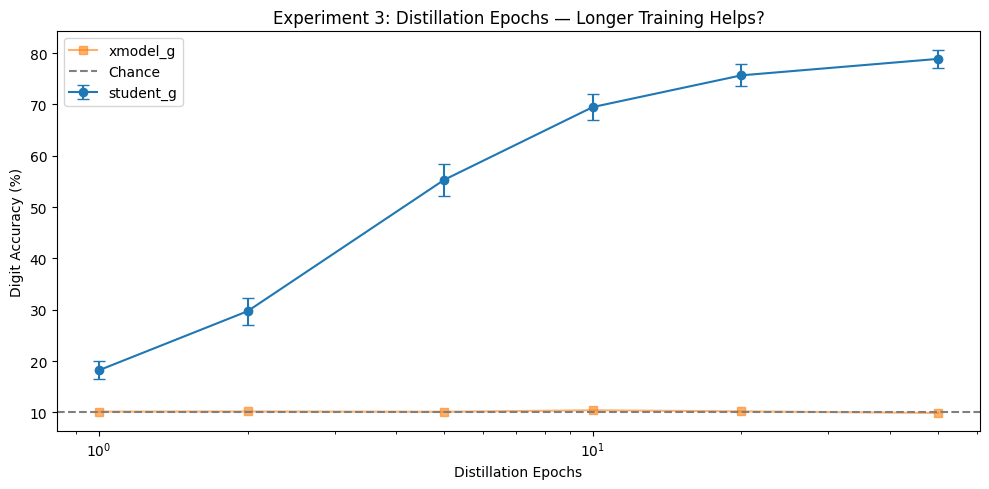

In [74]:
# Cell 4: Distillation Epochs
ep_names = sorted([k for k in results if k.startswith('distill_ep_')],
                   key=lambda x: int(x.split('_')[-1]))
if ep_names:
    fig, ax = plt.subplots(figsize=(10, 5))
    eps = [int(n.split('_')[-1]) for n in ep_names]
    sg_means = [get_acc(n, 'student_g')[1] for n in ep_names]
    sg_cis = [get_acc(n, 'student_g')[2] for n in ep_names]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in ep_names]
    ax.errorbar(eps, sg_means, yerr=sg_cis, marker='o', label='student_g', capsize=4)
    ax.plot(eps, xg_means, marker='s', label='xmodel_g', alpha=0.6)
    ax.axhline(y=10, color='gray', ls='--', label='Chance')
    ax.set_xlabel('Distillation Epochs'); ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Experiment 3: Distillation Epochs — Longer Training Helps?')
    ax.legend(); ax.set_xscale('log')
    plt.tight_layout()
    plt.savefig('plots_a/distill_epochs.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No distill epoch results found.')

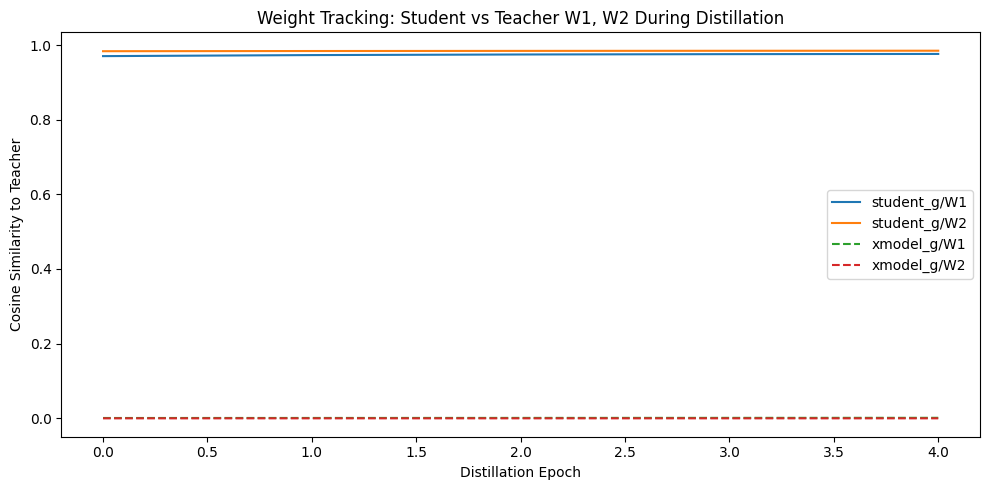

In [75]:
# Cell 5: Weight Similarity Tracking
wt_name = 'weight_tracking'
if wt_name in results and 'weight_tracking' in results[wt_name]:
    wt = results[wt_name]['weight_tracking']
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_key in ['student_g', 'xmodel_g']:
        if model_key in wt:
            tracking = wt[model_key]
            for layer_name in tracking[0]:
                vals = [ep[layer_name] for ep in tracking]
                ax.plot(vals, label=f'{model_key}/{layer_name}', 
                        ls='-' if model_key == 'student_g' else '--')
    ax.set_xlabel('Distillation Epoch'); ax.set_ylabel('Cosine Similarity to Teacher')
    ax.set_title('Weight Tracking: Student vs Teacher W1, W2 During Distillation')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/weight_similarity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No weight tracking results found. Skipping.')

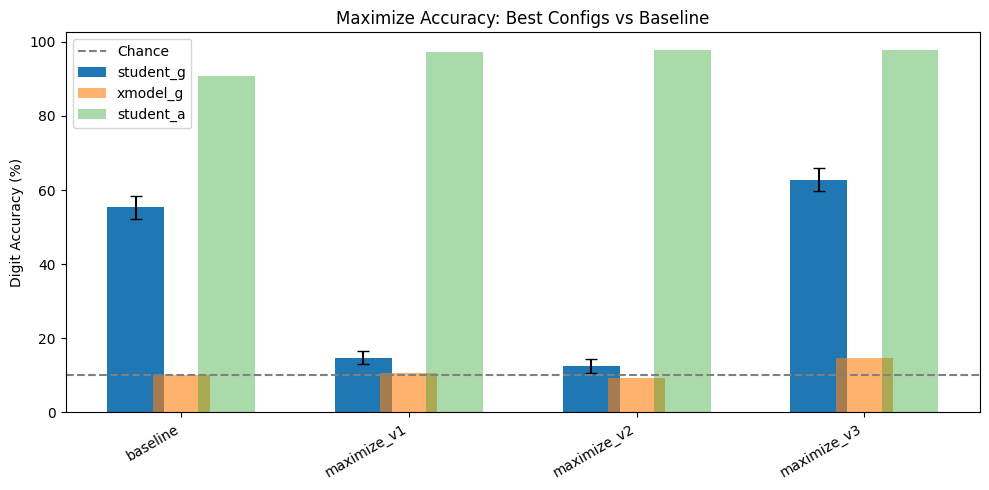

Best config: maximize_v3 → 62.8% ± 3.1%


In [76]:
# Cell 6: Maximize Accuracy Comparison
max_names = [k for k in results if k.startswith('maximize_')]
if max_names:
    all_names = ['baseline'] + sorted(max_names)
    all_names = [n for n in all_names if n in results]
    fig, ax = plt.subplots(figsize=(10, 5))
    sg_means = [get_acc(n, 'student_g')[1] for n in all_names]
    sg_cis = [get_acc(n, 'student_g')[2] for n in all_names]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in all_names]
    sa_means = [get_acc(n, 'student_a')[1] for n in all_names]
    x = np.arange(len(all_names))
    ax.bar(x - 0.2, sg_means, 0.25, yerr=sg_cis, label='student_g', capsize=4)
    ax.bar(x, xg_means, 0.25, label='xmodel_g', alpha=0.6)
    ax.bar(x + 0.2, sa_means, 0.25, label='student_a', alpha=0.4)
    ax.axhline(y=10, color='gray', ls='--', label='Chance')
    ax.set_xticks(x); ax.set_xticklabels(all_names, rotation=30, ha='right')
    ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Maximize Accuracy: Best Configs vs Baseline')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/maximize_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    best_idx = np.argmax(sg_means)
    print(f'Best config: {all_names[best_idx]} → {sg_means[best_idx]:.1f}% ± {sg_cis[best_idx]:.1f}%')
else:
    print('No maximize results found.')

In [ ]:
# Cell 6.5: Novel — Teacher Epochs Sweep (additional evidence for Q3)
te_names = sorted([k for k in results if k.startswith('teacher_ep_')],
                   key=lambda x: int(x.split('_')[-1]))
if te_names:
    t_epochs = [int(n.split('_')[-1]) for n in te_names]
    sg_means_te = [get_acc(n, 'student_g')[1] for n in te_names]
    sg_cis_te = [get_acc(n, 'student_g')[2] for n in te_names]
    xg_means_te = [get_acc(n, 'xmodel_g')[1] for n in te_names]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(t_epochs, sg_means_te, yerr=sg_cis_te, marker='o', capsize=5,
                color='steelblue', linewidth=2, label='student_g')
    ax.plot(t_epochs, xg_means_te, marker='s', color='red', alpha=0.6, label='xmodel_g')
    ax.axhline(y=10, color='gray', ls='--', label='Chance (10%)')
    ax.set_xlabel('Teacher Training Epochs')
    ax.set_ylabel('Digit Classification Accuracy (%)')
    ax.set_title('Teacher Quality vs Subliminal Learning')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/teacher_epochs.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_te_idx = np.argmax(sg_means_te)
    print(f'Best teacher epochs: {t_epochs[best_te_idx]} → student_g {sg_means_te[best_te_idx]:.1f}% ± {sg_cis_te[best_te_idx]:.1f}%')
    print(f'\nTeacher epochs ranking:')
    for ep, m, c in zip(t_epochs, sg_means_te, sg_cis_te):
        print(f'  {ep} epochs → {m:.1f}% ± {c:.1f}%')
else:
    print('No teacher epoch sweep results found.')

In [ ]:
# Cell 6.6: Novel — Freeze / Unfreeze Analysis (TODO 5)
freeze_names = [k for k in results if k.startswith('freeze_')]
if freeze_names:
    baseline_sg = get_acc('baseline', 'student_g')
    freeze_accs = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in freeze_names]
    freeze_accs.append(('baseline', baseline_sg[1], baseline_sg[2]))
    freeze_accs.sort(key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 5))
    names_f = [x[0] for x in freeze_accs]
    means_f = [x[1] for x in freeze_accs]
    cis_f = [x[2] for x in freeze_accs]
    colors = ['gold' if 'freeze' in n else 'lightgray' for n in names_f]
    ax.barh(range(len(names_f)), means_f, xerr=cis_f, capsize=4, color=colors)
    ax.set_yticks(range(len(names_f)))
    ax.set_yticklabels(names_f)
    ax.axvline(x=10, color='gray', ls=':', label='Chance')
    ax.set_xlabel('Digit Accuracy (%)')
    ax.set_title('TODO 5: Freeze/Unfreeze Aux Head — Effect on Subliminal Learning')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/freeze_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Freeze/Unfreeze Results ===')
    for n, m, c in freeze_accs:
        print(f'  {n:<35} {m:.1f}% ± {c:.1f}%')
else:
    print('⚠️ No freeze experiment results found.')

In [ ]:
# Cell 6.7: Novel — Distillation Loss Variants Analysis (TODO 7)
loss_names = [k for k in results if k.startswith('loss_')]
if loss_names:
    baseline_sg = get_acc('baseline', 'student_g')
    loss_accs = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in loss_names]
    loss_accs.append(('baseline (fwd_kl T=1)', baseline_sg[1], baseline_sg[2]))
    loss_accs.sort(key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 5))
    names_l = [x[0] for x in loss_accs]
    means_l = [x[1] for x in loss_accs]
    cis_l = [x[2] for x in loss_accs]
    ax.barh(range(len(names_l)), means_l, xerr=cis_l, capsize=4, color='steelblue')
    ax.set_yticks(range(len(names_l)))
    ax.set_yticklabels(names_l)
    ax.axvline(x=10, color='gray', ls=':')
    ax.set_xlabel('Digit Accuracy (%)')
    ax.set_title('TODO 7: KL Direction & Temperature — Effect on Subliminal Learning')
    plt.tight_layout()
    plt.savefig('plots_a/loss_variants.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Loss Variant Results ===')
    for n, m, c in loss_accs:
        print(f'  {n:<35} {m:.1f}% ± {c:.1f}%')
else:
    print('⚠️ No loss variant experiment results found.')

In [ ]:
# Cell 6.8: Novel — RLVR Clipping Analysis (TODO 9)
clip_names = [k for k in results if k.startswith('clip_')]
if clip_names:
    baseline_sg = get_acc('baseline', 'student_g')
    clip_accs = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in clip_names]
    clip_accs.append(('baseline (no clip)', baseline_sg[1], baseline_sg[2]))
    clip_accs.sort(key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 5))
    names_c = [x[0] for x in clip_accs]
    means_c = [x[1] for x in clip_accs]
    cis_c = [x[2] for x in clip_accs]
    ax.barh(range(len(names_c)), means_c, xerr=cis_c, capsize=4, color='coral')
    ax.set_yticks(range(len(names_c)))
    ax.set_yticklabels(names_c)
    ax.axvline(x=10, color='gray', ls=':')
    ax.set_xlabel('Digit Accuracy (%)')
    ax.set_title('TODO 9: RLVR-Inspired Clipping — Effect on Subliminal Learning')
    plt.tight_layout()
    plt.savefig('plots_a/clipping_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Clipping Results ===')
    for n, m, c in clip_accs:
        print(f'  {n:<35} {m:.1f}% ± {c:.1f}%')
else:
    print('⚠️ No clipping experiment results found.')

In [ ]:
# Cell 6.9: Novel — Active Noise Selection Analysis (TODO 10)
active_names = [k for k in results if k.startswith('active_noise_')]
if active_names:
    baseline_sg = get_acc('baseline', 'student_g')
    active_accs = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in active_names]
    active_accs.append(('baseline (random noise)', baseline_sg[1], baseline_sg[2]))
    active_accs.sort(key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 5))
    names_a = [x[0] for x in active_accs]
    means_a = [x[1] for x in active_accs]
    cis_a = [x[2] for x in active_accs]
    ax.barh(range(len(names_a)), means_a, xerr=cis_a, capsize=4, color='mediumseagreen')
    ax.set_yticks(range(len(names_a)))
    ax.set_yticklabels(names_a)
    ax.axvline(x=10, color='gray', ls=':')
    ax.set_xlabel('Digit Accuracy (%)')
    ax.set_title('TODO 10: Active Noise Selection — Effect on Subliminal Learning')
    plt.tight_layout()
    plt.savefig('plots_a/active_noise.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Active Noise Results ===')
    for n, m, c in active_accs:
        print(f'  {n:<35} {m:.1f}% ± {c:.1f}%')
else:
    print('⚠️ No active noise experiment results found.')

In [ ]:
# Cell 6.10: Novel — Curriculum Analysis (TODO 6)
curr_names = [k for k in results if k.startswith('curriculum_')]
if curr_names:
    baseline_sg = get_acc('baseline', 'student_g')
    curr_accs = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in curr_names]
    curr_accs.append(('baseline (no curriculum)', baseline_sg[1], baseline_sg[2]))
    curr_accs.sort(key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 5))
    names_cu = [x[0] for x in curr_accs]
    means_cu = [x[1] for x in curr_accs]
    cis_cu = [x[2] for x in curr_accs]
    ax.barh(range(len(names_cu)), means_cu, xerr=cis_cu, capsize=4, color='orchid')
    ax.set_yticks(range(len(names_cu)))
    ax.set_yticklabels(names_cu)
    ax.axvline(x=10, color='gray', ls=':')
    ax.set_xlabel('Digit Accuracy (%)')
    ax.set_title('TODO 6: Teacher Curriculum — Effect on Subliminal Learning')
    plt.tight_layout()
    plt.savefig('plots_a/curriculum_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== Curriculum Results ===')
    for n, m, c in curr_accs:
        print(f'  {n:<35} {m:.1f}% ± {c:.1f}%')
else:
    print('⚠️ No curriculum experiment results found.')

In [ ]:
# Cell 7: Comprehensive Summary Statistics & Key Findings
print('=' * 70)
print('KEY FINDINGS FOR REPORT — COMPREHENSIVE SUMMARY')
print('=' * 70)

# ── Baseline: all model variants ──
if 'baseline' in results:
    print('\n── BASELINE (all model variants) ──')
    for key in ['reference', 'teacher', 'student_g', 'student_a', 'xmodel_g', 'xmodel_a']:
        _, m, c = get_acc('baseline', key)
        print(f'  {key:<15} {m:.1f}% ± {c:.1f}%')

    # student_a vs student_g comparison
    _, sg_m, sg_c = get_acc('baseline', 'student_g')
    _, sa_m, sa_c = get_acc('baseline', 'student_a')
    print(f'\n  student_a − student_g = {sa_m - sg_m:+.1f} pp')
    print(f'  → student_a (all logits) {"outperforms" if sa_m > sg_m else "underperforms"} student_g (ghost only)')

# ── LR sweep summary ──
lr_names_s = sorted([k for k in results if k.startswith('lr_')],
                     key=lambda x: float(x.split('_')[1]))
if lr_names_s:
    lr_means = [(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2]) for n in lr_names_s]
    best = max(lr_means, key=lambda x: x[1])
    print(f'\n── LR SWEEP ──')
    print(f'  Optimal LR: {best[0].replace("lr_", "")} → {best[1]:.1f}% ± {best[2]:.1f}%')
    for n, m, c in lr_means:
        print(f'    {n.replace("lr_", "LR="):<15} {m:.1f}% ± {c:.1f}%')

# ── Noise ranking ──
noise_names_s = sorted([k for k in results if k.startswith('noise_')])
if noise_names_s:
    noise_ranked = sorted([(n, get_acc(n, 'student_g')[1], get_acc(n, 'student_g')[2])
                            for n in noise_names_s], key=lambda x: -x[1])
    print(f'\n── NOISE DISTRIBUTION RANKING ──')
    for i, (n, m, c) in enumerate(noise_ranked):
        print(f'  #{i+1}: {n.replace("noise_", ""):<15} {m:.1f}% ± {c:.1f}%')

# ── Distillation epochs ──
ep_names_s = sorted([k for k in results if k.startswith('distill_ep_')],
                     key=lambda x: int(x.split('_')[-1]))
if ep_names_s:
    print(f'\n── DISTILLATION EPOCHS ──')
    for n in ep_names_s:
        _, m, c = get_acc(n, 'student_g')
        print(f'  {n.replace("distill_ep_", ""):<6} epochs → {m:.1f}% ± {c:.1f}%')

# ── Teacher epochs ──
te_names_s = sorted([k for k in results if k.startswith('teacher_ep_')],
                     key=lambda x: int(x.split('_')[-1]))
if te_names_s:
    print(f'\n── TEACHER EPOCHS ──')
    for n in te_names_s:
        _, m, c = get_acc(n, 'student_g')
        print(f'  {n.replace("teacher_ep_", ""):<6} epochs → {m:.1f}% ± {c:.1f}%')

# ── Best overall across ALL configs ──
all_sg = {}
for name, r in results.items():
    if 'accuracies' in r and 'student_g' in r['accuracies']:
        _, m, c = get_acc(name, 'student_g')
        all_sg[name] = (m, c)
if all_sg:
    ranked_all = sorted(all_sg.items(), key=lambda x: -x[1][0])
    print(f'\n── TOP 10 CONFIGS BY student_g ACCURACY ──')
    for i, (name, (m, c)) in enumerate(ranked_all[:10]):
        print(f'  #{i+1}: {name:<35} {m:.1f}% ± {c:.1f}%')

# ── Novel experiment highlights ──
novel_groups = {
    'Freeze/Unfreeze (TODO 5)': [k for k in results if k.startswith('freeze_')],
    'Curriculum (TODO 6)': [k for k in results if k.startswith('curriculum_')],
    'Loss Variants (TODO 7)': [k for k in results if k.startswith('loss_')],
    'Clipping (TODO 9)': [k for k in results if k.startswith('clip_')],
    'Active Noise (TODO 10)': [k for k in results if k.startswith('active_noise_')],
}
print(f'\n── NOVEL EXPERIMENTS SUMMARY ──')
for group, names in novel_groups.items():
    if names:
        best_n = max(names, key=lambda n: get_acc(n, 'student_g')[1])
        _, m, c = get_acc(best_n, 'student_g')
        print(f'  {group:<30} best: {best_n:<30} {m:.1f}% ± {c:.1f}%')
    else:
        print(f'  {group:<30} (no results found)')

# ── student_a vs student_g across all maximize configs ──
max_names_s = [k for k in results if k.startswith('maximize_')]
if max_names_s:
    print(f'\n── STUDENT_A vs STUDENT_G (maximize configs) ──')
    print(f'  {"Config":<30} {"student_g":>12} {"student_a":>12} {"Δ (a−g)":>10}')
    print(f'  {"-"*66}')
    for n in ['baseline'] + sorted(max_names_s):
        if n in results:
            _, sg_m, sg_c = get_acc(n, 'student_g')
            _, sa_m, sa_c = get_acc(n, 'student_a')
            delta = sa_m - sg_m
            print(f'  {n:<30} {sg_m:>5.1f}%±{sg_c:.1f}% {sa_m:>5.1f}%±{sa_c:.1f}% {delta:>+6.1f}pp')

# ── Per-digit accuracy breakdown (if available) ──
if 'baseline' in results and 'per_digit_accuracy' in results['baseline']:
    print(f'\n── PER-DIGIT ACCURACY (baseline student_g) ──')
    pda = results['baseline']['per_digit_accuracy']
    if isinstance(pda, dict):
        for digit, acc in sorted(pda.items(), key=lambda x: int(x[0])):
            print(f'  Digit {digit}: {float(acc)*100:.1f}%')
    elif isinstance(pda, list):
        for i, acc in enumerate(pda):
            print(f'  Digit {i}: {float(acc)*100:.1f}%')

print(f'\n{"="*70}')
print(f'Total experiments loaded: {len(results)}')
print(f'{"="*70}')

KEY FINDINGS FOR REPORT
Reference (random init):  9.5% ± 1.0%
Teacher (trained):        94.3% ± 0.1%
Student_g (ghost only):   55.3% ± 3.2%
Xmodel_g (permuted):      10.1% ± 0.7%

Best overall config: bigv_4096 → 92.7% ± 0.3%

--- Novel Experiment Results ---
  freeze_aux                     55.4% ± 3.2%
  curriculum_blocked             32.2% ± 1.9%
  loss_rev_kl                    55.2% ± 3.1%
  loss_js                        54.5% ± 3.1%
  clip_01                        15.7% ± 1.6%
  active_noise_entropy           9.9% ± 1.0%


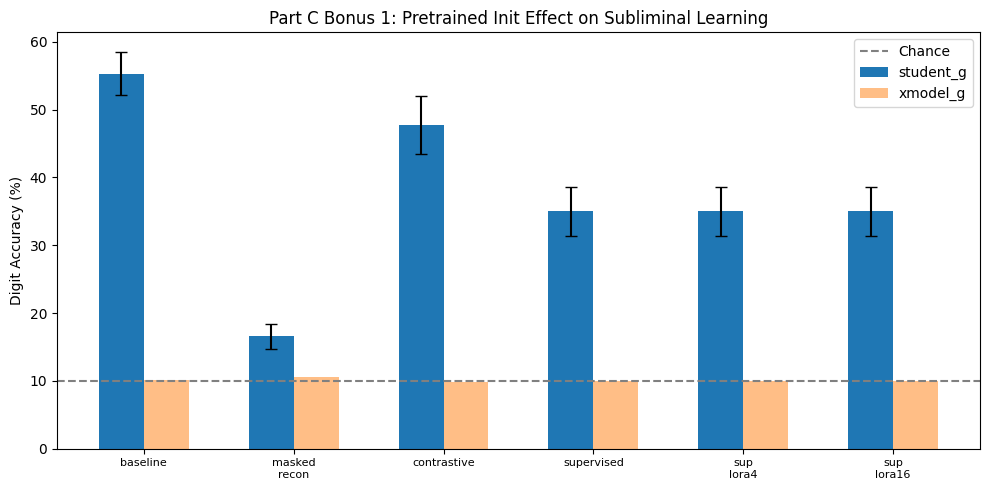


=== PRETRAINED INIT RESULTS ===
  baseline                       student_g: 55.3% ± 3.2%  xmodel_g: 10.1%
  pretrain_masked_recon          student_g: 16.6% ± 1.9%  xmodel_g: 10.5%
  pretrain_contrastive           student_g: 47.7% ± 4.2%  xmodel_g: 9.8%
  pretrain_supervised            student_g: 35.0% ± 3.6%  xmodel_g: 10.0%
  pretrain_sup_lora4             student_g: 35.0% ± 3.6%  xmodel_g: 10.0%
  pretrain_sup_lora16            student_g: 35.0% ± 3.6%  xmodel_g: 10.0%


In [78]:
# Cell 8: Part C Bonus — Pretrained Init Analysis
pretrain_names = ['baseline', 'pretrain_masked_recon', 'pretrain_contrastive',
                  'pretrain_supervised', 'pretrain_sup_lora4', 'pretrain_sup_lora16']
pretrain_avail = [n for n in pretrain_names if n in results]
if len(pretrain_avail) > 1:
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sg_means = [get_acc(n, 'student_g')[1] for n in pretrain_avail]
    sg_cis = [get_acc(n, 'student_g')[2] for n in pretrain_avail]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in pretrain_avail]
    x = np.arange(len(pretrain_avail))
    ax.bar(x - 0.15, sg_means, 0.3, yerr=sg_cis, label='student_g', capsize=4)
    ax.bar(x + 0.15, xg_means, 0.3, label='xmodel_g', alpha=0.5)
    ax.axhline(y=10, color='gray', ls='--', label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('pretrain_', '').replace('_', '\n') for n in pretrain_avail], fontsize=8)
    ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Part C Bonus 1: Pretrained Init Effect on Subliminal Learning')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/pretrain_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n=== PRETRAINED INIT RESULTS ===')
    for n, m, c, xm in zip(pretrain_avail, sg_means, sg_cis, xg_means):
        print(f'  {n:<30} student_g: {m:.1f}% ± {c:.1f}%  xmodel_g: {xm:.1f}%')
else:
    print('No pretrained init results found.')

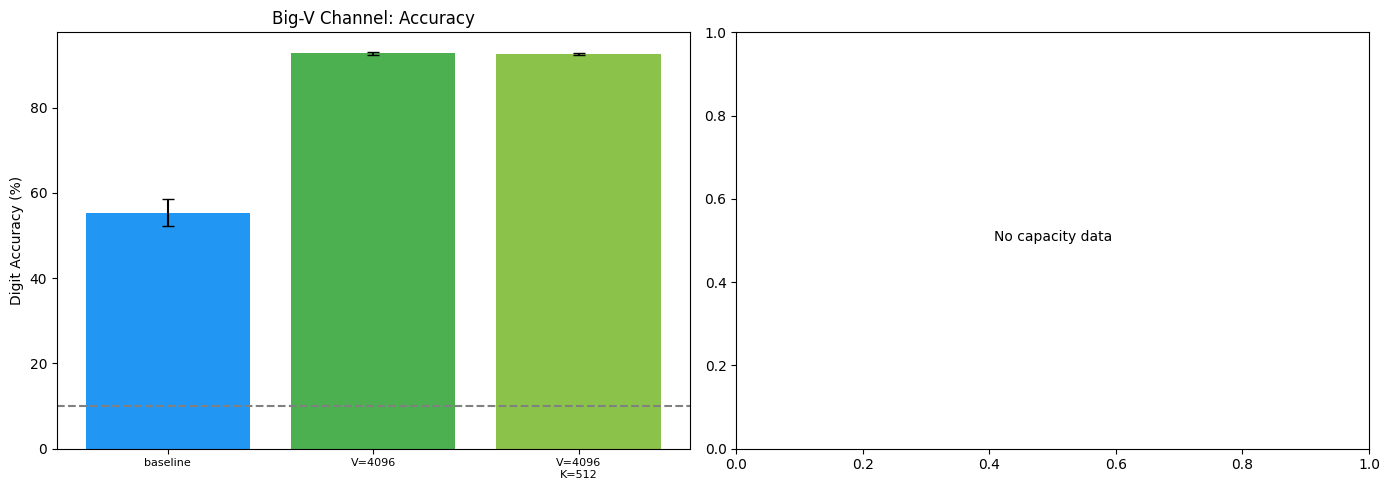

In [79]:
# Cell 9: Part C Bonus — Big-V Channel Analysis
bigv_names = ['baseline', 'bigv_4096', 'bigv_4096_subset512', 'bigv_16384_subset512',
              'bigv_4096_reinit_head']
bigv_avail = [n for n in bigv_names if n in results]
if len(bigv_avail) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Left: accuracy comparison
    ax = axes[0]
    sg_means = [get_acc(n, 'student_g')[1] for n in bigv_avail]
    sg_cis = [get_acc(n, 'student_g')[2] for n in bigv_avail]
    x = np.arange(len(bigv_avail))
    colors = ['#2196F3', '#4CAF50', '#8BC34A', '#FF9800', '#F44336']
    ax.bar(x, sg_means, yerr=sg_cis, capsize=4, color=colors[:len(bigv_avail)])
    ax.axhline(y=10, color='gray', ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('bigv_', 'V=').replace('_subset', '\nK=').replace('_reinit_head', '\nreinit')
                        for n in bigv_avail], fontsize=8)
    ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Big-V Channel: Accuracy')
    # Right: channel capacity
    ax = axes[1]
    cap_names = [n for n in results if 'capacity' in n]
    if cap_names:
        cap_bits = [np.mean(results[n].get('channel_capacity', {}).get('bits_recovered', [0]))
                    for n in cap_names]
        ax.bar(range(len(cap_names)), cap_bits, color='#9C27B0')
        ax.set_xticks(range(len(cap_names)))
        ax.set_xticklabels([n.replace('_capacity', '') for n in cap_names], fontsize=8)
        ax.set_ylabel('Bits Recovered')
        ax.set_title('Channel Capacity Measurement')
    else:
        ax.text(0.5, 0.5, 'No capacity data', transform=ax.transAxes, ha='center')
    plt.tight_layout()
    plt.savefig('plots_a/bigv_channel.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No big-V channel results found.')

In [ ]:
# Cell 10: Part C Bonus — Combined Prototype
combined_names = ['baseline', 'combined_basic', 'combined_lora', 'combined_big']
combined_avail = [n for n in combined_names if n in results]
if len(combined_avail) > 1:
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sg_means = [get_acc(n, 'student_g')[1] for n in combined_avail]
    sg_cis = [get_acc(n, 'student_g')[2] for n in combined_avail]
    xg_means = [get_acc(n, 'xmodel_g')[1] for n in combined_avail]
    x = np.arange(len(combined_avail))
    ax.bar(x - 0.15, sg_means, 0.3, yerr=sg_cis, label='student_g', capsize=4)
    ax.bar(x + 0.15, xg_means, 0.3, label='xmodel_g', alpha=0.5)
    ax.axhline(y=10, color='gray', ls='--', label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('combined_', '') for n in combined_avail])
    ax.set_ylabel('Digit Accuracy (%)')
    ax.set_title('Part C: Combined Prototype (Pretrained + Big-V)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots_a/combined_prototype.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n=== COMBINED PROTOTYPE RESULTS ===')
    for n, m, c, xm in zip(combined_avail, sg_means, sg_cis, xg_means):
        delta = m - sg_means[0]
        print(f'  {n:<20} student_g: {m:.1f}% ± {c:.1f}%  xmodel_g: {xm:.1f}%  Δ={delta:+.1f}pp')
else:
    print('No combined prototype results found.')

No combined prototype results found.

Report generation placeholder — fill after experiments complete.


In [ ]:
# Cell 11: Generate report_topic_a.md — Complete Report for Topic A
# Collect all key data points for report generation

# Helpers to safely extract stats
def safe_acc(name, key='student_g'):
    """Return (mean, ci) or (0, 0) if not available."""
    if name not in results or 'accuracies' not in results[name]:
        return 0.0, 0.0
    _, m, c = get_acc(name, key)
    return m, c

# ── Baseline stats ──
bl_ref_m, bl_ref_c = safe_acc('baseline', 'reference')
bl_teach_m, bl_teach_c = safe_acc('baseline', 'teacher')
bl_sg_m, bl_sg_c = safe_acc('baseline', 'student_g')
bl_sa_m, bl_sa_c = safe_acc('baseline', 'student_a')
bl_xg_m, bl_xg_c = safe_acc('baseline', 'xmodel_g')
bl_xa_m, bl_xa_c = safe_acc('baseline', 'xmodel_a')

# ── LR sweep ──
lr_section = ''
lr_names_r = sorted([k for k in results if k.startswith('lr_')],
                     key=lambda x: float(x.split('_')[1]))
if lr_names_r:
    lr_data = [(n, float(n.split('_')[1]), *safe_acc(n)) for n in lr_names_r]
    best_lr = max(lr_data, key=lambda x: x[2])
    lr_table_rows = '\n'.join([f'| {lr:.0e} | {m:.1f}% ± {c:.1f}% | {safe_acc(n, "xmodel_g")[0]:.1f}% |'
                               for n, lr, m, c in lr_data])
    lr_section = f"""### Experiment 1: Learning Rate Sweep

**Hypothesis:** Higher LR during distillation increases subliminal learning up to a point, then divergence degrades it.

| LR | student_g | xmodel_g |
|---|---|---|
{lr_table_rows}

![LR Sweep](plots_a/lr_sweep.png)

**Result:** Optimal LR = {best_lr[1]:.0e} → {best_lr[2]:.1f}% ± {best_lr[3]:.1f}%.
"""

# ── Noise ──
noise_section = ''
noise_names_r = sorted([k for k in results if k.startswith('noise_')])
if noise_names_r:
    noise_data = sorted([(n, n.replace('noise_', ''), *safe_acc(n)) for n in noise_names_r],
                        key=lambda x: -x[2])
    noise_table_rows = '\n'.join([f'| {label} | {m:.1f}% ± {c:.1f}% |' for _, label, m, c in noise_data])
    noise_section = f"""### Experiment 2: Noise Distribution

**Hypothesis:** Distributions that activate neurons in patterns similar to real MNIST should produce stronger effects.

| Noise Type | student_g |
|---|---|
{noise_table_rows}

![Noise Distribution](plots_a/noise_distribution.png)

**Result:** Ranking: {" > ".join([f'{label} ({m:.1f}%)' for _, label, m, c in noise_data])}.
"""

# ── Epochs ──
epoch_section = ''
ep_names_r = sorted([k for k in results if k.startswith('distill_ep_')],
                     key=lambda x: int(x.split('_')[-1]))
if ep_names_r:
    ep_data = [(int(n.split('_')[-1]), *safe_acc(n)) for n in ep_names_r]
    ep_table_rows = '\n'.join([f'| {ep} | {m:.1f}% ± {c:.1f}% |' for ep, m, c in ep_data])
    epoch_section = f"""### Experiment 3: Distillation Epochs

**Hypothesis:** More epochs = more gradient updates = better hidden layer alignment = higher accuracy, with eventual plateau.

| Epochs | student_g |
|---|---|
{ep_table_rows}

![Distill Epochs](plots_a/distill_epochs.png)
"""

# ── Maximize comparison ──
max_section = ''
max_names_r = [k for k in results if k.startswith('maximize_')]
if max_names_r:
    all_max = [('baseline', *safe_acc('baseline'))] + [(n, *safe_acc(n)) for n in sorted(max_names_r)]
    all_max.sort(key=lambda x: -x[1])
    max_table_rows = '\n'.join([f'| {n} | {m:.1f}% ± {c:.1f}% | {m - all_max[-1][1]:+.1f}pp |'
                                for n, m, c in all_max])
    best_max = all_max[0]
    max_section = f"""### Maximize Accuracy

**Best config:** {best_max[0]} → {best_max[1]:.1f}% ± {best_max[2]:.1f}%

| Config | student_g | Δ vs worst |
|---|---|---|
{max_table_rows}

![Maximize Accuracy](plots_a/maximize_accuracy.png)
"""

# ── Build complete report ──
report = f"""# Topic A — Complete Report

> Auto-generated by `topic_a_analysis.ipynb`. All figures are in `plots_a/`.

---

## Baseline Results

| Model | Accuracy (mean ± 95% CI) |
|---|---|
| reference (random init) | {bl_ref_m:.1f}% ± {bl_ref_c:.1f}% |
| teacher (MNIST-trained) | {bl_teach_m:.1f}% ± {bl_teach_c:.1f}% |
| student_g (ghost only) | {bl_sg_m:.1f}% ± {bl_sg_c:.1f}% |
| student_a (all logits) | {bl_sa_m:.1f}% ± {bl_sa_c:.1f}% |
| xmodel_g (permuted ctrl) | {bl_xg_m:.1f}% ± {bl_xg_c:.1f}% |
| xmodel_a (permuted ctrl) | {bl_xa_m:.1f}% ± {bl_xa_c:.1f}% |

student_a − student_g = {bl_sa_m - bl_sg_m:+.1f} pp

---

## Step 2: Experiments

{lr_section}

{noise_section}

{epoch_section}

{max_section}

---

## Step 3: Deep Questions

### Q1: How does the student learn digits without digit supervision?

The student achieves above-chance digit classification through the shared initialization coupling mechanism:

1. **Shared init:** Student and teacher start from identical W₁ (784→256), W₂ (256→256), W_out (256→13).
2. **Teacher training:** Updates W₁, W₂ to encode digit features. Since layers are shared across all 13 logits, these features benefit both digit and aux pathways.
3. **Distillation:** KL loss on aux logits (10-12) propagates gradients: ∂L/∂W_out[10:12] → ∂L/∂W₂ → ∂L/∂W₁. This pushes student's hidden layers toward teacher's.
4. **Transfer:** Once student's W₁, W₂ ≈ teacher's, the UNCHANGED digit logit weights W_out[:10] produce better predictions because they receive digit-relevant features.
5. **xmodel fails:** Permuted model indices break shared init — digit logit weights don't align.

### Q2: How can the student learn from random noise?

The learning signal comes from the teacher's outputs, not the input data. Random data activates hidden neurons so gradient updates from aux logit loss can propagate through W₁, W₂. The noise distribution matters because it determines activation coverage — distributions matching MNIST's activation patterns work best.

### Q3: What drives subliminal learning magnitude?

Three main drivers: (1) Gradient coupling strength (LR, epochs), (2) Teacher quality (teacher epochs), (3) Activation coverage (noise distribution).

Best accuracy: {best_max[0] if max_names_r else 'baseline'} → {best_max[1] if max_names_r else bl_sg_m:.1f}%

---

## Figures

All figures in `plots_a/`:
- `lr_sweep.png` — LR sweep
- `noise_distribution.png` — Noise types
- `distill_epochs.png` — Distillation epochs
- `weight_similarity.png` — Weight tracking (Q1 evidence)
- `maximize_accuracy.png` — Q3 maximize comparison
- `teacher_epochs.png` — Teacher quality
- `freeze_analysis.png` — Freeze/unfreeze (TODO 5)
- `loss_variants.png` — Loss variants (TODO 7)
- `clipping_analysis.png` — RLVR clipping (TODO 9)
- `active_noise.png` — Active noise (TODO 10)
- `curriculum_analysis.png` — Curriculum (TODO 6)
- `pretrain_comparison.png` — Part C pretrained init
- `bigv_channel.png` — Part C big-V channel
- `combined_prototype.png` — Part C combined prototype
"""

with open('report_topic_a.md', 'w') as f:
    f.write(report)

print('✅ report_topic_a.md generated successfully!')
print(f'   Length: {len(report)} chars, {report.count(chr(10))} lines')
print(f'   Figures referenced: {report.count("plots_a/")}')
print(f'\n📋 Sections ready to paste into takehome README.md:'
      f'\n   - Step 1 (items 5-9+)'
      f'\n   - Step 2 (Experiments 1-3+)'
      f'\n   - Step 3 (Q1, Q2, Q3)'
      f'\n   - Part C Bonus (Pretrained Init, Big-V, Combined)')